# Delivery Time Predictor — Exploratory Data Analysis (EDA)

**Goal of a notebook:** *understand the data before you model it.* Notebooks are lab equipment, not products — we explore here, then move the stable code into `.py` files (`src/features.py`, `src/pipeline.py`).

Coming from Flutter: think of this as the throwaway `main()` you write to poke at an API response before you design the real widgets.

We want to answer:
1. How messy is the raw data, and how do we clean it?
2. What does the thing we predict (`Time_taken`) look like?
3. Which columns actually explain delivery time? (distance, traffic, weather, festival…)

> Run this notebook from the **project root** so `import src...` works.

In [1]:
import sys, os
# Make sure the project root is importable when the kernel starts inside notebooks/
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("cwd:", os.getcwd())

cwd: /Users/rudraveersinghsandhu/PycharmProjects/DeliveryTimePredictor


## 1. Look at the raw data first (see the mess)

Never clean data you haven't looked at. Notice the junk: trailing spaces (`'High '`), a `'(min) 24'` target, `'conditions Sunny'`, and the literal string `'NaN'`.

In [2]:
raw = pd.read_csv("data/train.csv")
print("shape:", raw.shape)
raw.head()

shape: (45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [3]:
# The target column, untouched — you can't model '(min) 24' as a number.
raw["Time_taken(min)"].head()

0    (min) 24
1    (min) 33
2    (min) 26
3    (min) 21
4    (min) 30
Name: Time_taken(min), dtype: str

## 2. Clean it with our reusable function

Instead of cleaning inline (and forgetting a step later), we call the SAME `load_and_clean` the training script uses. One source of truth.

In [4]:
from src.features import load_and_clean, LATE_THRESHOLD_MIN

df = load_and_clean("data/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            44977 non-null  str    
 12  Road_traffic_density         44992 non-null  str    
 13  Vehicle_condition          

In [5]:
# Missing values per column, worst first. Real data always has gaps.
df.isna().sum().sort_values(ascending=False).head(12)

Restaurant_latitude            3640
Restaurant_longitude           3640
Delivery_location_latitude     3640
Delivery_location_longitude    3640
Delivery_person_Ratings        1908
Delivery_person_Age            1854
Time_Orderd                    1731
City                           1200
multiple_deliveries             993
Weatherconditions               616
Road_traffic_density            601
Festival                        228
dtype: int64

## 3. The target: how long do deliveries take?

This is what the **regressor** predicts. We also draw the 30-minute line — orders to the right of it are "late", which the **classifier** predicts.

count    45593.00
mean        26.29
std          9.38
min         10.00
25%         19.00
50%         26.00
75%         32.00
max         54.00
Name: time_taken_min, dtype: float64

Fraction of orders over 30 min ("late"): 29.8%


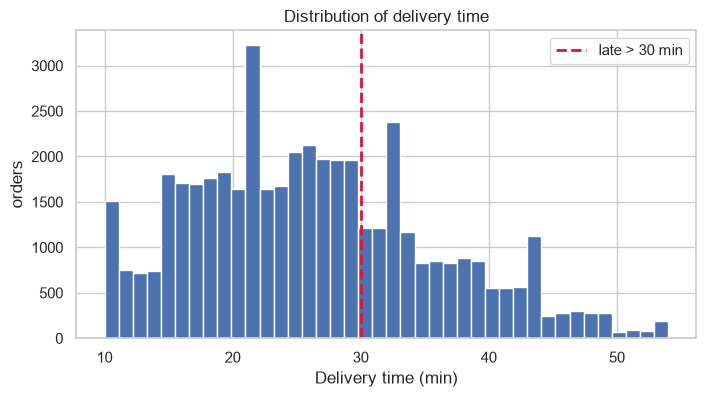

In [6]:
t = df["time_taken_min"].dropna()
print(t.describe().round(2))
late_frac = (t > LATE_THRESHOLD_MIN).mean()
print(f"\nFraction of orders over {LATE_THRESHOLD_MIN} min (\"late\"): {late_frac:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(t, bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(LATE_THRESHOLD_MIN, color="crimson", ls="--", lw=2, label=f"late > {LATE_THRESHOLD_MIN} min")
ax.set_xlabel("Delivery time (min)"); ax.set_ylabel("orders"); ax.set_title("Distribution of delivery time")
ax.legend(); plt.show()

The ~30% late rate is a healthy split for classification — not a rare event, so the model has plenty of both classes to learn from.

## 4. Engineer distance and see if it matters

Four raw GPS columns are useless to a tree model as-is. We collapse them into one **haversine distance** using the same transformer the pipeline uses.

corr(distance, time): 0.321


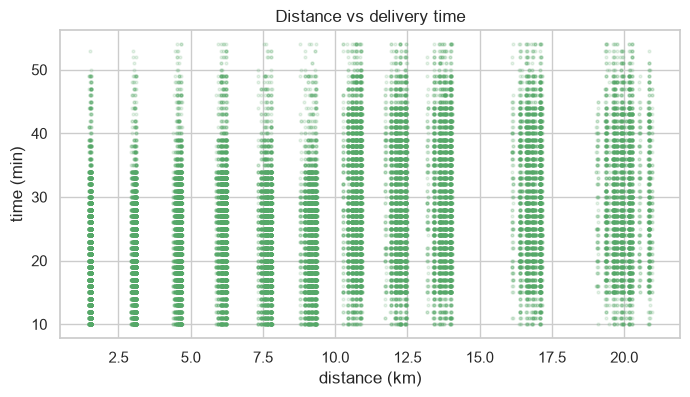

In [7]:
from src.features import haversine_km

d = df.dropna(subset=["Restaurant_latitude", "Restaurant_longitude",
                       "Delivery_location_latitude", "Delivery_location_longitude",
                       "time_taken_min"]).copy()
d["distance_km"] = haversine_km(d["Restaurant_latitude"], d["Restaurant_longitude"],
                                  d["Delivery_location_latitude"], d["Delivery_location_longitude"])
# Most real deliveries are within ~25 km; clip the long tail for a readable plot.
d = d[d["distance_km"] < 25]
print("corr(distance, time):", round(d["distance_km"].corr(d["time_taken_min"]), 3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(d["distance_km"], d["time_taken_min"], s=4, alpha=0.15, color="#55A868")
ax.set_xlabel("distance (km)"); ax.set_ylabel("time (min)"); ax.set_title("Distance vs delivery time")
plt.show()

## 5. Categorical drivers: traffic, weather, festival

Group by each category and look at the average delivery time. Big gaps between groups = strong predictive signal.

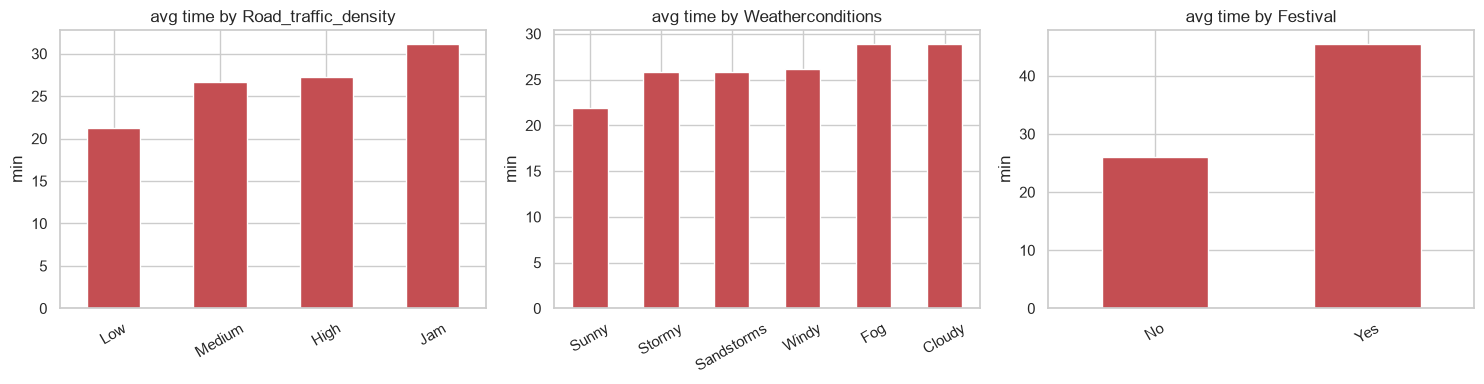

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, order in [
    (axes[0], "Road_traffic_density", ["Low", "Medium", "High", "Jam"]),
    (axes[1], "Weatherconditions", None),
    (axes[2], "Festival", ["No", "Yes"]),
]:
    g = df.groupby(col)["time_taken_min"].mean().sort_values()
    if order:
        g = g.reindex([o for o in order if o in g.index])
    g.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"avg time by {col}"); ax.set_ylabel("min"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

Traffic jams and festivals add a lot of time — exactly the intuition the model confirmed (traffic & festival were its top features).

## 6. Numeric correlations

A quick heatmap of how the numeric fields move with delivery time.

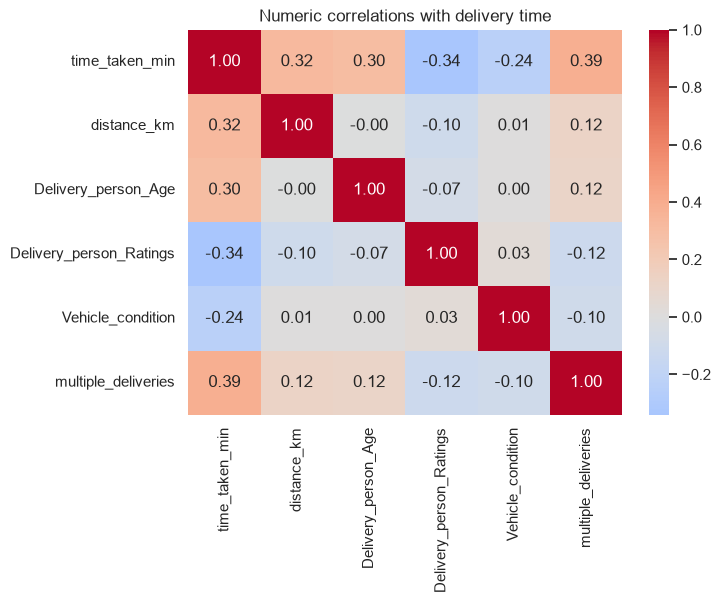

In [9]:
num = d[["time_taken_min", "distance_km", "Delivery_person_Age",
          "Delivery_person_Ratings", "Vehicle_condition", "multiple_deliveries"]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(num, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric correlations with delivery time"); plt.show()

## 7. Takeaways → what goes into the model

- **Lower ratings** and **more simultaneous deliveries** → longer times.
- **Traffic, weather, festival** are strong categorical signals → one-hot encode them.
- **Distance** is a solid positive driver → keep the engineered `distance_km`.
- The raw GPS / date / time columns are only useful once engineered.

All of this is now baked into `src/features.py` (cleaning + feature engineering) and `src/pipeline.py` (encoding + model). The notebook was just to *justify* those choices. Next stop: `python -m src.train`.